# 3. Exploración de Datos (EDA)

En esta sección se realiza un análisis exploratorio para entender el comportamiento de las variables
y su relación con la variable objetivo `default`. Se incluyen visualizaciones y estadísticas descriptivas.

In [4]:
df = pd.read_csv("../data/accepted_clean.csv")

C:\Users\PC\AppData\Local\Temp\ipykernel_25432\3812611707.py:1: DtypeWarning: Columns (0: desc, 1: verification_status_joint, 2: sec_app_earliest_cr_line, 3: hardship_type, 4: hardship_reason, 5: hardship_status, 6: hardship_start_date, 7: hardship_end_date, 8: payment_plan_start_date, 9: hardship_loan_status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/accepted_clean.csv")


## 3.1 Preparación para el EDA

Debido al tamaño del dataset, para algunas visualizaciones se utilizará una muestra aleatoria.
Esto acelera la exploración sin perder la representatividad general.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (Opcional) ajustar opciones de visualización
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# Mostrar tamaño actual (ya filtrado a Fully Paid / Charged Off)
print("Dimensiones (filtrado):", df.shape)

# Muestra para gráficos (ajusta si tu PC aguanta más)
df_eda = df.sample(n=200000, random_state=42) if len(df) > 200000 else df.copy()

print("Dimensiones muestra EDA:", df_eda.shape)

Dimensiones (filtrado): (1293629, 152)
Dimensiones muestra EDA: (200000, 152)


El dataset filtrado cuenta con **1,293,629 registros y 152 columnas**. Dado el volumen de datos, 
se extrae una **muestra aleatoria de 200,000 registros** (`random_state=42`) para las 
visualizaciones del EDA, garantizando reproducibilidad sin sacrificar la representatividad 
de la distribución general.

## 3.2 Estadística descriptiva

Se resumen estadísticas básicas de variables numéricas para observar rangos, dispersión y posibles outliers.

In [5]:
df_eda.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
id,200000.0,5.487633e+07,3.845529e+07,55716.00,18301868.00,55585071.00,78378550.00,1.456204e+08
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,200000.0,1.445271e+04,8.699760e+03,700.00,8000.00,12000.00,20000.00,4.000000e+04
funded_amnt,200000.0,1.444469e+04,8.695753e+03,700.00,8000.00,12000.00,20000.00,4.000000e+04
funded_amnt_inv,200000.0,1.442060e+04,8.699244e+03,0.00,7975.00,12000.00,20000.00,4.000000e+04
int_rate,200000.0,1.319150e+01,4.743012e+00,5.31,9.67,12.74,15.99,3.099000e+01
installment,200000.0,4.388483e+02,2.608002e+02,14.01,249.55,375.54,581.77,1.719830e+03
annual_inc,200000.0,7.619160e+04,6.595870e+04,0.00,45900.00,65000.00,90000.00,8.300000e+06
dti,199941.0,1.826186e+01,1.035878e+01,-1.00,11.79,17.62,24.04,9.990000e+02
delinq_2yrs,200000.0,3.161500e-01,8.780621e-01,0.00,0.00,0.00,0.00,2.700000e+01


La estadística descriptiva de las primeras 20 variables numéricas permite identificar 
varios patrones relevantes:

- **`loan_amnt`:** Los préstamos oscilan entre $700 y $40,000, con una mediana de $12,000, 
  lo que indica una distribución moderadamente asimétrica hacia valores altos.
- **`int_rate`:** La tasa de interés promedio es de 13.19%, con valores entre 5.31% y 30.99%, 
  reflejando una amplia variabilidad según el perfil de riesgo del solicitante.
- **`annual_inc`:** El ingreso anual presenta una dispersión muy alta (std ≈ $65,958) y un 
  máximo de $8.3M, lo que sugiere la presencia de **outliers extremos**.
- **`dti`:** El ratio deuda-ingreso tiene un máximo de 999, valor atípico que deberá ser 
  tratado en el preprocesamiento.
- **`fico_range_low/high`:** Los scores FICO se concentran entre 660 y 850, con una mediana 
  alrededor de 690-694, indicando una base de clientes de riesgo moderado.
- **`mths_since_last_delinq` y `mths_since_last_record`:** Presentan una cantidad 
  significativa de valores nulos (solo ~98K y ~33K registros con datos respectivamente), 
  lo que refleja que muchos clientes no tienen historial de morosidad o registros públicos.

En general, se observan **distribuciones asimétricas y presencia de outliers** en varias 
variables, lo que requerirá transformaciones durante el preprocesamiento.

## 3.3 Distribución del target

Se revisa nuevamente la distribución de la variable objetivo para evidenciar el desbalance de clases.

,count,percent
default,,
0,1076751,80.04
1,268559,19.96


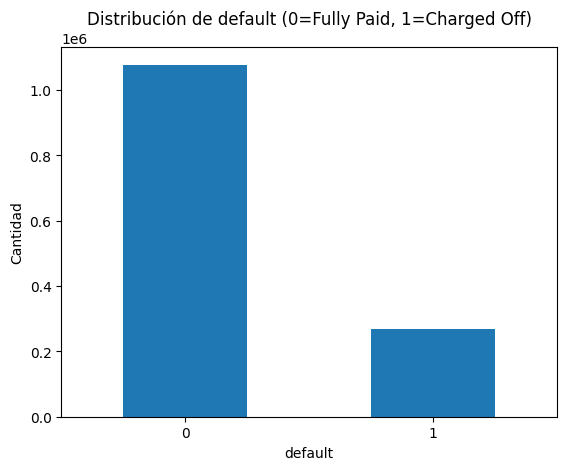

In [6]:
counts = df["default"].value_counts()
props = df["default"].value_counts(normalize=True) * 100

display(pd.DataFrame({"count": counts, "percent": props.round(2)}))

counts.plot(kind="bar")
plt.title("Distribución de default (0=Fully Paid, 1=Charged Off)")
plt.xticks([0,1], ["0", "1"], rotation=0)
plt.ylabel("Cantidad")
plt.show()

La distribución del target sobre el dataset completo confirma los resultados previos:

| Clase | Descripción | Cantidad | Porcentaje |
|-------|-------------|----------|------------|
| 0 | Fully Paid | 1,076,751 | 80.04% |
| 1 | Charged Off | 268,559 | 19.96% |

El gráfico refuerza visualmente el desbalance, donde la clase mayoritaria (no default) 
cuadruplica a la clase minoritaria (default). Este desequilibrio se tendrá en cuenta 
durante el modelado para evitar que el clasificador se sesgue hacia la clase dominante.

## 3.4 Valores faltantes

Se identifican las variables con mayor porcentaje de valores nulos para decidir estrategias de limpieza.

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "missing_values": missing,
    "missing_pct": missing_pct
}).head(20)

missing_table

,missing_values,missing_pct
member_id,1345310,100.000000
next_pymnt_d,1345310,100.000000
orig_projected_additional_accrued_interest,1341551,99.720585
hardship_amount,1339556,99.572292
hardship_last_payment_amount,1339556,99.572292
hardship_length,1339556,99.572292
hardship_status,1339556,99.572292
hardship_reason,1339556,99.572292
deferral_term,1339556,99.572292
hardship_start_date,1339556,99.572292


Las 20 variables con mayor porcentaje de nulos corresponden principalmente a tres grupos:

- **Columnas completamente vacías** (`member_id`, `next_pymnt_d`): 100% nulos, serán eliminadas.
- **Variables de dificultad financiera** (`hardship_*`, `deferral_term`, `payment_plan_start_date`): 
  ~99.57% nulos — aplican solo a casos excepcionales de reestructuración.
- **Variables de solicitud conjunta** (`sec_app_*`, `revol_bal_joint`): ~98.6% nulos — 
  representan co-solicitantes, categoría minoritaria en el dataset.

Todas estas columnas superan el umbral del **95% de valores faltantes**, por lo que serán 
eliminadas en la etapa de preprocesamiento para evitar introducir ruido en los modelos.

## 3.5 Histogramas de variables numéricas

Se visualizan distribuciones de variables numéricas relevantes para entender su comportamiento.
Se recomienda incluir variables como: `loan_amnt`, `int_rate`, `annual_inc`, `dti`.

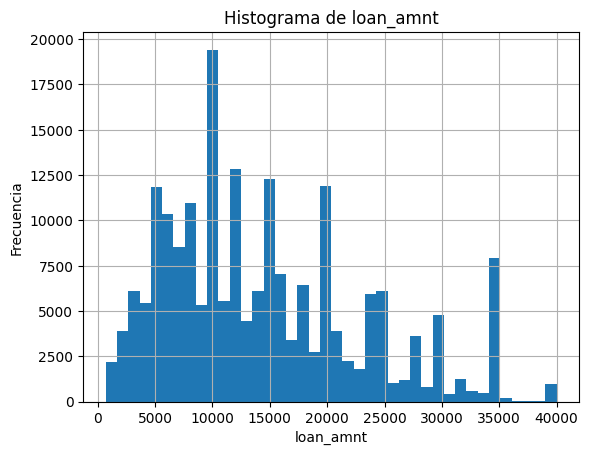

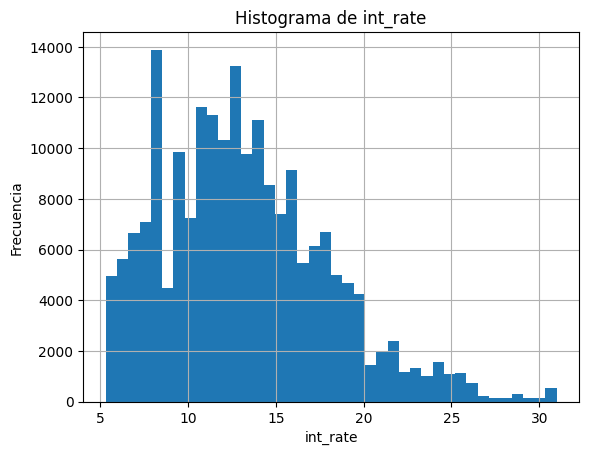

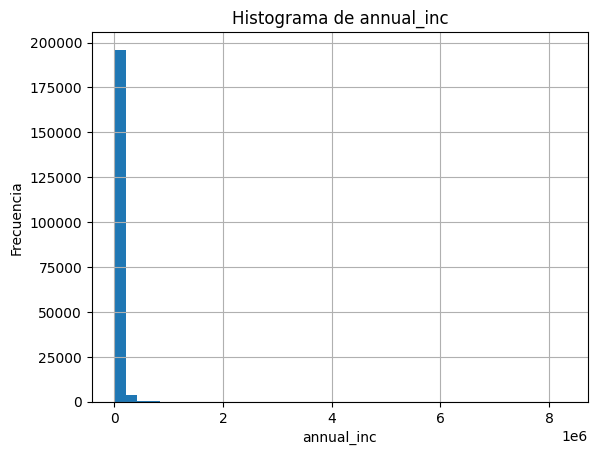

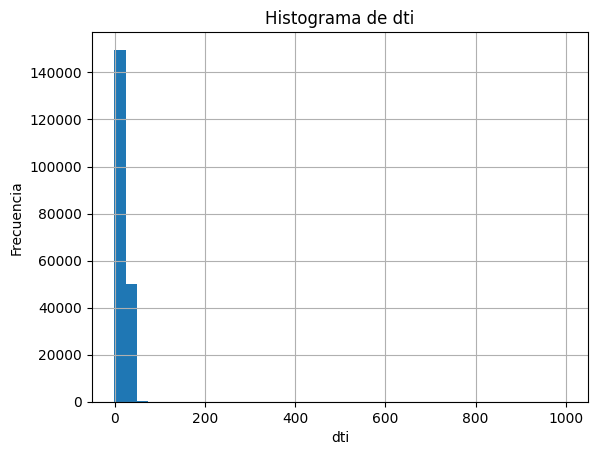

In [8]:
num_vars = ["loan_amnt", "int_rate", "annual_inc", "dti"]

for col in num_vars:
    if col in df_eda.columns:
        df_eda[col].dropna().hist(bins=40)
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.show()

Los histogramas de las cuatro variables numéricas clave revelan los siguientes patrones:

- **`loan_amnt`:** Distribución multimodal con picos en valores redondos ($5,000, $10,000, 
  $15,000, $20,000), lo que refleja que los solicitantes tienden a pedir montos enteros 
  específicos. La mayor concentración se da entre $5,000 y $20,000.

- **`int_rate`:** Distribución sesgada a la derecha con mayor concentración entre el 7% y 
  15%. Tasas superiores al 20% son menos frecuentes, correspondiendo a perfiles de mayor 
  riesgo crediticio.

- **`annual_inc`:** Distribución extremadamente sesgada a la derecha, con la gran mayoría 
  de los ingresos concentrados por debajo de $200,000, pero con outliers extremos que 
  alcanzan los $8.3M. Esto requiere una transformación logarítmica o recorte de valores 
  atípicos antes del modelado.

- **`dti`:** Similar a `annual_inc`, presenta una fuerte asimetría positiva con la mayoría 
  de los valores entre 0 y 60, pero con outliers extremos cercanos a 1000, que 
  corresponden a registros erróneos o casos excepcionales que deberán ser filtrados.

## 3.6 Boxplots por clase

Se comparan variables numéricas entre clases (`default=0` vs `default=1`) para detectar diferencias
en medianas y dispersión.

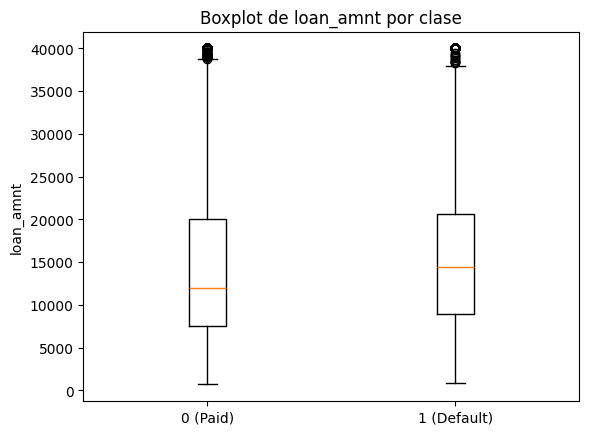

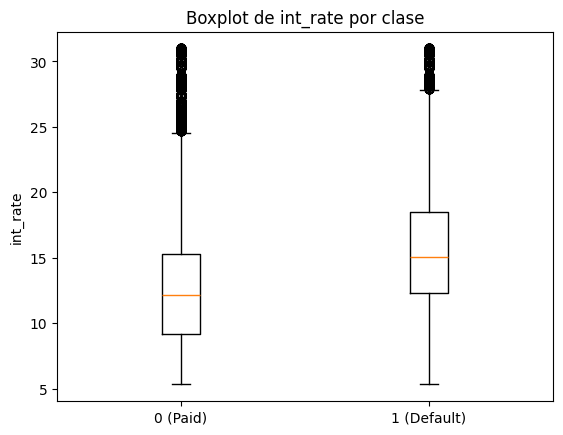

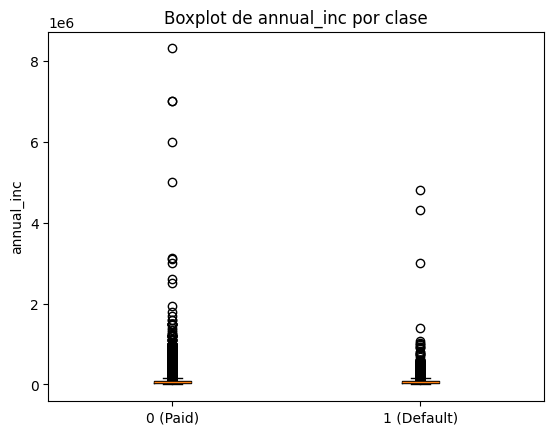

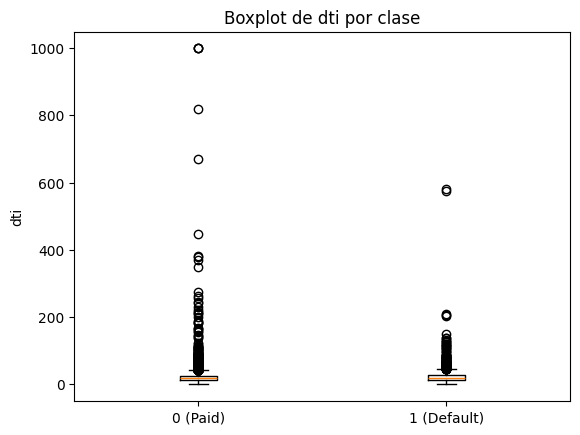

In [9]:
def boxplot_by_class(df_in, col, target="default"):
    data0 = df_in[df_in[target] == 0][col].dropna()
    data1 = df_in[df_in[target] == 1][col].dropna()

    plt.boxplot([data0, data1], tick_labels=["0 (Paid)", "1 (Default)"])
    plt.title(f"Boxplot de {col} por clase")
    plt.ylabel(col)
    plt.show()

for col in ["loan_amnt", "int_rate", "annual_inc", "dti"]:
    if col in df_eda.columns:
        boxplot_by_class(df_eda, col)

Los boxplots por clase permiten identificar diferencias en la distribución de cada variable 
según el comportamiento de pago:

- **`loan_amnt`:** Ambas clases presentan distribuciones muy similares con medianas cercanas 
  a $12,000-$14,000. El monto del préstamo por sí solo **no parece ser un factor 
  diferenciador** claro entre clientes que pagan y los que incumplen.

- **`int_rate`:** Se observa una diferencia notable. Los clientes en **default presentan 
  una mediana más alta** (~15%) frente a los que pagan (~12%), lo que sugiere que tasas 
  de interés elevadas están asociadas a mayor riesgo de incumplimiento. Esta variable 
  será probablemente **una de las más importantes** para el modelo.

- **`annual_inc`:** En ambas clases los valores se concentran en rangos bajos con outliers 
  extremos. No se aprecian diferencias marcadas entre clases, aunque la presencia masiva 
  de outliers en ambos grupos refuerza la necesidad de tratamiento de valores atípicos.

- **`dti`:** Similar a `annual_inc`, ambas clases muestran distribuciones concentradas 
  cerca de 0-50 con outliers extremos (hasta 1000). No hay una diferencia visual clara 
  entre clases, aunque el rango intercuartílico de la clase default parece ligeramente 
  superior, lo que podría indicar una leve tendencia a mayor endeudamiento relativo.

## 3.7 Variables categóricas vs default

Se exploran variables categóricas importantes y su relación con la probabilidad de default.
Ejemplos típicos: `grade`, `sub_grade`, `home_ownership`, `purpose`.

In [10]:
def default_rate_by_category(df_in, cat_col, target="default", top_n=15):
    tmp = (
        df_in[[cat_col, target]]
        .dropna()
        .groupby(cat_col)[target]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )
    tmp["default_rate_pct"] = (tmp["mean"] * 100).round(2)
    return tmp.head(top_n)

for col in ["grade", "home_ownership", "purpose"]:
    if col in df.columns:
        display(default_rate_by_category(df, col, top_n=15))

,count,mean,default_rate_pct
grade,,,
B,392741,0.133852,13.39
C,381686,0.224396,22.44
A,235090,0.060407,6.04
D,200953,0.303822,30.38
E,93650,0.384784,38.48
F,32058,0.452024,45.20
G,9132,0.499343,49.93


,count,mean,default_rate_pct
home_ownership,,,
MORTGAGE,665579,0.172077,17.21
RENT,534421,0.232165,23.22
OWN,144832,0.206198,20.62
ANY,286,0.195804,19.58
OTHER,144,0.187500,18.75
NONE,48,0.145833,14.58


,count,mean,default_rate_pct
purpose,,,
debt_consolidation,780321,0.211469,21.15
credit_card,295279,0.169270,16.93
home_improvement,87504,0.177158,17.72
other,77875,0.210401,21.04
major_purchase,29425,0.185998,18.60
medical,15554,0.217757,21.78
small_business,15416,0.297094,29.71
car,14585,0.146795,14.68
moving,9480,0.233544,23.35


El análisis de la tasa de default por variable categórica revela patrones muy informativos:

**`grade` (calificación crediticia):**  
Es la variable con mayor poder discriminativo. Existe una relación casi perfectamente 
monotónica entre la calificación y el riesgo: desde un 6.04% de default en grado **A** 
hasta un 49.93% en grado **G**. Esto confirma que el sistema de calificación de Lending 
Club es altamente predictivo del incumplimiento.

**`home_ownership` (tenencia de vivienda):**  
Los arrendatarios (**RENT**) presentan la mayor tasa de default (23.22%), seguidos de 
propietarios sin hipoteca (**OWN**, 20.62%). Quienes tienen hipoteca (**MORTGAGE**) 
muestran el menor riesgo (17.21%), posiblemente por representar un perfil financiero 
más estable. Las categorías minoritarias (ANY, OTHER, NONE) tienen escasa representación.

**`purpose` (propósito del préstamo):**  
Los préstamos para **pequeños negocios** (`small_business`) registran la tasa más alta 
(29.71%), seguidos de **mudanzas** (23.35%) y **energía renovable** (23.69%). Por el 
contrario, préstamos para **bodas** (12.16%) y **autos** (14.68%) presentan los menores 
niveles de incumplimiento. La **consolidación de deuda**, siendo la categoría más 
frecuente (780,321 registros), tiene una tasa moderada del 21.15%.

## 3.8 Correlaciones

Se calcula la correlación entre variables numéricas y la variable `default` para identificar posibles
predictores relevantes.

In [11]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr = df[num_cols].corr(numeric_only=True)

# Correlación con default (top 15 por magnitud)
corr_default = corr["default"].dropna().sort_values(key=lambda s: s.abs(), ascending=False)
corr_default.head(15)

default                                       1.000000
last_fico_range_high                         -0.667842
last_fico_range_low                          -0.575706
recoveries                                    0.505415
collection_recovery_fee                       0.480216
total_rec_prncp                              -0.438944
last_pymnt_amnt                              -0.347385
total_pymnt                                  -0.315180
total_pymnt_inv                              -0.314751
int_rate                                      0.258792
sec_app_fico_range_low                       -0.251242
sec_app_fico_range_high                      -0.251242
hardship_dpd                                  0.244754
hardship_amount                               0.173362
orig_projected_additional_accrued_interest    0.172316
Name: default, dtype: float64

Las correlaciones con la variable `default` revelan predictores relevantes, aunque es 
importante distinguir entre variables con **fuga de información** (*data leakage*) y 
variables genuinamente predictivas:

**⚠️ Variables con data leakage** (información post-evento que no estaría disponible 
al momento de otorgar el préstamo):
- `last_fico_range_high/low` (-0.67, -0.58): Score FICO actualizado tras el incumplimiento.
- `recoveries` y `collection_recovery_fee` (+0.51, +0.48): Montos recuperados tras el default.
- `total_rec_prncp`, `last_pymnt_amnt`, `total_pymnt` (-0.44, -0.35, -0.32): Reflejan 
  el comportamiento de pago posterior al otorgamiento del crédito.

Estas variables **deberán ser excluidas** del modelo para evitar un rendimiento 
artificialmente inflado.

**✅ Variables predictoras legítimas:**
- `int_rate` (+0.26): Mayor tasa de interés → mayor probabilidad de default. Consistente 
  con el análisis previo de boxplots.
- `hardship_dpd` y `hardship_amount` (+0.24, +0.17): Relacionadas con dificultades 
  financieras activas, aunque con alta tasa de nulos.

En conclusión, el preprocesamiento deberá **eliminar las variables con leakage** para 
garantizar que el modelo aprenda patrones genuinamente predictivos.

## 3.9 Hallazgos preliminares

- Se observó el desbalance de clases en `default`.
- Variables como `int_rate`, `grade`, `dti` y `annual_inc` suelen mostrar diferencias entre clases.
- Existen variables con altos porcentajes de nulos que requerirán estrategia de limpieza o eliminación.
- Se identificaron variables numéricas con correlación notable con `default` (se analizarán en modelado).